# Creating RERECIST Line from Mask

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from skimage.measure import regionprops 
from skimage.draw import line
from pathlib import Path

## Helper Functions

In [3]:
def pad_bbox(box:np.array,
             mask:np.array, 
             padding:int,
             spacing:np.array = None
             ) -> np.array:
    # Get full image dimensions to keep padding within image size
    # D, H, W (z, y, x)
    mask_shape = mask.shape

    if spacing is not None: # Use the actual image spacing to calculate the padding
        # Check that spacing can be applied to this mask's bounding box dimensions
        if len(spacing) < len(mask_shape):
            spacing = spacing[0, len(mask_shape)]
        elif len(spacing) > len(mask_shape):
            message = "Spacing for padding has more dimensions than the mask image."
            raise ValueError(message)

        # calculate the number of voxels to pad based on the actual image spacing
        padding = np.round(padding / spacing)
    else:
        # Convert padding into an array with the same length as image dimensions
        # This matches the behaviour of the spacing option
        padding = padding * np.ones(len(mask_shape))
    
    pad_x_min = max(0, box[0] - padding[0])
    pad_y_min = max(0, box[1] - padding[1])
    # Handling 2D bounding box
    if len(box) == 4:
        mask_H, mask_W = mask_shape[0], mask_shape[1]
        pad_x_max = min(mask_W, box[2] + padding[0])
        pad_y_max = min(mask_H, box[3] + padding[1])

        padded_box = np.array([pad_x_min, pad_y_min,
                               pad_x_max, pad_y_max])

    # Handling 3D bounding box
    if len(box) == 6:
        mask_D, mask_H, mask_W = mask_shape[0], mask_shape[1], mask_shape[2]
        pad_z_min = max(0, box[2] - padding[2])
        pad_x_max = min(mask_W, box[3] + padding[0])
        pad_y_max = min(mask_H, box[4] + padding[1]) 
        pad_z_max = min(mask_D, box[5] + padding[2])
        
        padded_box = np.array([pad_x_min, pad_y_min, pad_z_min,
                               pad_x_max, pad_y_max, pad_z_max])

    return padded_box.astype(int)



def mask2D_to_bbox(gt2D:np.array, 
                   mask_path:Path, 
                   padding:int | None = None,
                   spacing:np.array = None
                   ) -> np.array:
    try:
        ## Old code 
        # y_indices, x_indices = np.where(gt2D > 0)
        # x_min, x_max = np.min(x_indices), np.max(x_indices)
        # y_min, y_max = np.min(y_indices), np.max(y_indices)
        # boxes = np.array([x_min, y_min, x_max, y_max])

        props = regionprops(gt2D)[0]
        y_cent, x_cent = props.centroid
        orientation = props.orientation
        semi_maj_axis_len = props.major_axis_length / 2

        x_start = x_cent - np.sin(orientation) * semi_maj_axis_len
        y_start = y_cent - np.cos(orientation) * semi_maj_axis_len

        x_end = x_cent + np.sin(orientation) * semi_maj_axis_len
        y_end = y_cent + np.cos(orientation) * semi_maj_axis_len

        boxes = np.array([x_start, y_start, x_end, y_end])
        
        if padding:
            boxes = pad_bbox(box = boxes,
                             mask = gt2D,
                             padding = padding,
                             spacing = spacing)
        
        return boxes.astype(int)
    except Exception as e:
        raise Exception(f'error {e} with file {mask_path} and sum of gts is {gt2D.sum()}')



def mask3D_to_bbox(gt3D:np.array, 
                   mask_path:Path, 
                   padding:int | None = None,
                   spacing:np.array = None
                   ) -> np.array:
    try:
         # Find slices in the mask that have label voxels to get z boundaries
        z_indices, _, _ = np.where(gt3D > 0)
        z_min, z_max = np.min(z_indices), np.max(z_indices)
    except Exception as e:
        raise Exception(f'error {e} with file {mask_path} and sum of gts is {gt3D.sum()}')
   
    # Find the centre slice of the mask
    z_mid = np.median(z_indices).astype(int)
    # Select out this slice from the array
    gt_mid = gt3D[z_mid]

    # Get the x and y mask boundaries using the 2D function
    box_2d = mask2D_to_bbox(gt_mid, mask_path)
    x_min, y_min, x_max, y_max = box_2d
    boxes3D = np.array([x_min, y_min, z_min, x_max, y_max, z_max])

    if padding:
        # Apply padding to bounding box if requested
        boxes3D = pad_bbox(box = boxes3D,
                           mask = gt3D,
                           padding = padding,
                           spacing = spacing)
    
    return boxes3D.astype(int)


def get_line_from_recist(recist_coords: np.array, 
                         slice_number: int, 
                         img_size: np.array):
    '''
    From the RECIST measurement coordinates, generate a line connecting both coordinates on the correct slice and return an np.ndarray the same shape as the image.
    Output to be compatible with the ['recist'] array of the .npz files needed for MedSAM2-RECIST.

    Parameters
    ----------
    recist_coords: array
        A list of coordinates in [x1, y1, x2, y2] format that defines the RECIST measurement 
    slice_number: int
        The slice that the measurement was taken on
    img_size: np.array
        The x, y, and z size of the image in [z_space, x_space, y_space] format
    
    Returns
    ----------
    recist_arr: np.ndarray
        A binary array of the same shape as the image with the pixels of the line = 1
    '''
    #Generate an array in the same size as the image filled with all zeros 
    recist_arr = np.zeros((img_size[0], img_size[1], img_size[2]), dtype = int)
    
    #Round the coordinate values to their nearest integers 
    coords_round = np.rint(recist_coords).astype(int)

    #Draw line using coordinates 
    rr, cc = line(coords_round[0], coords_round[1], coords_round[2], coords_round[3])

    #Put line into the correct slice in the RECIST array of all zeros 
    recist_arr[slice_number][cc, rr] = 1

    return recist_arr

In [4]:
def find_first_last_slice(mask): 
    axes = tuple([i for i in range(mask.ndim) if i != 0])

    slices = mask.any(axis = axes) 

    nonzero_indices = np.where(slices)[0]

    first_slice = np.amin(nonzero_indices)
    last_slice = np.amax(nonzero_indices) 

    return first_slice, last_slice

In [5]:
def array_to_coords(data):
    for y, line in enumerate(data):
        for x, point in enumerate(line):
            if point == 1:
                yield(x, y)

# Testing RERECIST Line Generation

In [6]:
# Import example image and mask
test_path = '/home/bhkuser/bhklab/kaitlyn/bhklab-nninteractive/C3N-00494_0033_RTSTRUCT_812952.npz'
npz_info = np.load(test_path)

img = npz_info['imgs']
mask = npz_info['gts'] 

bbox = mask3D_to_bbox(gt3D = mask, 
                      mask_path = test_path)

# Get slice that the measurement is on
z_minmax = [bbox[2], bbox[5]]
z_mid = np.median(z_minmax).astype(int)

coords = [bbox[0], bbox[1], bbox[3], bbox[4]]
rere_line = get_line_from_recist(coords, 
                                 z_mid, 
                                 img.shape)


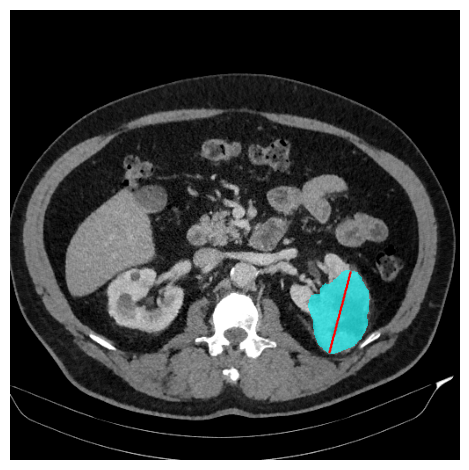

In [7]:
line_data = list(array_to_coords(rere_line[z_mid]))

x, y = zip(*line_data)

fig = plt.figure() 

colours = ['cyan']
cmap = mcolors.ListedColormap(colours)

mask = np.ma.masked_where(mask == 0, mask)
plt.imshow(np.clip(img[z_mid], -135, 215), cmap = 'gray') 
plt.imshow(mask[z_mid], cmap = cmap, interpolation = 'nearest', alpha = 0.6)
plt.plot(x, y, 'r')
plt.axis("off") 
plt.tight_layout()
plt.show()